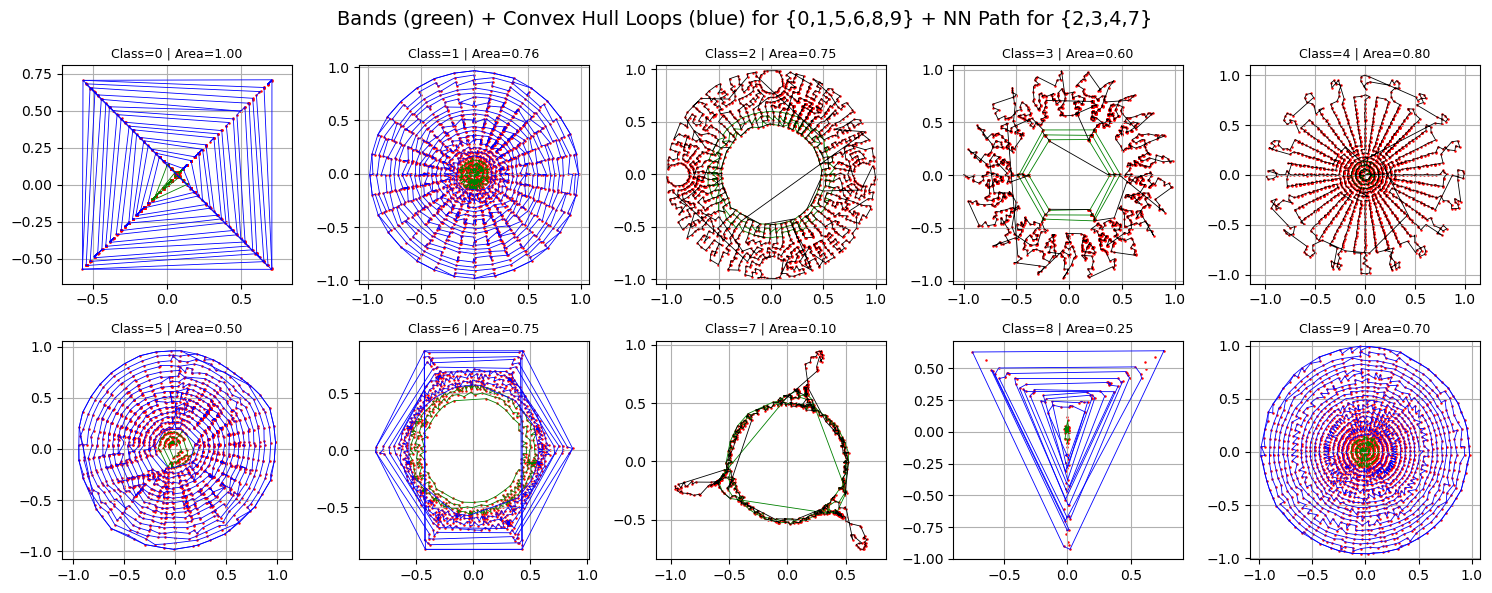

In [4]:
# =====================================================
# Inference: C-WGAN-GP (Conditional)
# Bands (green) + Convex Hull + Nested Loops (blue) for
# {0,1,5,6,8,9}, and Nearest Neighbor (blue) for {2,3,4,7}.
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.spatial import ConvexHull, distance

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt")

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2030
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"
# =====================================================
# Load Models
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()
# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Band Method
# =====================================================
def multilayer_bands_origin(points, band_width=0.05, max_layers=3):
    """Build multiple circular layers from origin (0,0)."""
    dists = np.sqrt(points[:,0]**2 + points[:,1]**2)
    r1 = dists.min()

    loops = []
    band_indices = set()

    for k in range(max_layers):
        low = r1 + k*band_width
        high = r1 + (k+1)*band_width

        band_mask = (dists >= low) & (dists <= high)
        band_points = points[band_mask]

        if len(band_points) > 3:
            angles = np.arctan2(band_points[:,1], band_points[:,0])
            order = np.argsort(angles)
            loop = band_points[order]
            loop = np.vstack([loop, loop[0]])
            loops.append(loop)
            band_indices.update(np.where(band_mask)[0])  # track indices

    return loops, points, band_indices, r1

# =====================================================
# Nested Loops with Convex Hull
# =====================================================
def nested_loops_with_hull(points, band_indices, r_band, step=0.05):
    """Outer convex hull, then inward shells until band."""
    dists = np.sqrt(points[:,0]**2 + points[:,1]**2)
    r_max = dists.max()

    # ignore band points
    mask = np.ones(len(points), dtype=bool)
    mask[list(band_indices)] = False
    pts = points[mask]
    dists = dists[mask]

    layers = []

    # Outermost convex hull
    if len(pts) > 3:
        try:
            hull = ConvexHull(pts)
            hull_points = pts[hull.vertices]
            hull_ordered = np.vstack([hull_points, hull_points[0]])
            layers.append(hull_ordered)
        except:
            pass

    # Inward shells
    r_current = r_max
    while r_current > r_band:
        shell_mask = (dists <= r_current) & (dists > r_current - step)
        shell_points = pts[shell_mask]

        if len(shell_points) > 3:
            angles = np.arctan2(shell_points[:,1], shell_points[:,0])
            order = np.argsort(angles)
            loop = shell_points[order]
            loop = np.vstack([loop, loop[0]])
            layers.append(loop)

        r_current -= step

    return layers

# =====================================================
# Nearest Neighbor Path
# =====================================================
def nearest_neighbor_path(points):
    """Connect all points using a simple nearest neighbor walk."""
    if len(points) < 2:
        return None

    remaining = list(range(len(points)))
    path = [remaining.pop(0)]  # start at first point

    while remaining:
        last = path[-1]
        dists = distance.cdist([points[last]], points[remaining])[0]
        nearest_idx = remaining[np.argmin(dists)]
        path.append(nearest_idx)
        remaining.remove(nearest_idx)

    loop = points[path]
    return loop

# =====================================================
# Generate One Sample per Class
# =====================================================
with torch.no_grad():
    z_noise = torch.randn(num_classes, latent_size).to(device)
    labels = torch.arange(num_classes)
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float().to(device)

    #areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.35, 0.25, 0.7]    
    areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.10, 0.25, 0.7] 

    areas_dummy = torch.tensor(areas_list, dtype=torch.float32).view(num_classes, 1).to(device)

    conds = torch.cat([areas_dummy, labels_onehot], dim=1)
    fake_latents = G(z_noise, conds)
    decoded = cae(fake_latents, conds).cpu().numpy()

# =====================================================
# Plot Results
# =====================================================
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 6))

nested_classes = {0, 1, 5, 6, 8, 9}
nn_classes = {2, 3, 4, 7}

for i in range(num_classes):
    r, c = divmod(i, cols)
    pts = np.unique(np.round(decoded[i], 6), axis=0)

    # Always apply band method
    loops, all_pts, band_indices, r_band = multilayer_bands_origin(pts, band_width=0.05, max_layers=3)
    axs[r, c].scatter(all_pts[:,0], all_pts[:,1], s=0.6, color="red")
    for loop in loops:
        axs[r, c].plot(loop[:,0], loop[:,1], '-', lw=0.6, color="green")

    # Nested + Convex Hull method
    if i in nested_classes:
        layers = nested_loops_with_hull(all_pts, band_indices, r_band, step=0.05)
        for layer in layers:
            axs[r, c].plot(layer[:,0], layer[:,1], '-', color="blue", lw=0.6)

    # Nearest Neighbor method
    if i in nn_classes:
        path = nearest_neighbor_path(all_pts)
        if path is not None:
            axs[r, c].plot(path[:,0], path[:,1], '-', color="black", lw=0.6)

    axs[r, c].set_title(f"Class={i} | Area={areas_list[i]:.2f}", fontsize=9)
    axs[r, c].axis("equal")
    axs[r, c].grid(True)

plt.suptitle("Bands (green) + Convex Hull Loops (blue) for {0,1,5,6,8,9} + NN Path for {2,3,4,7}", fontsize=14)
plt.tight_layout()
plt.show()


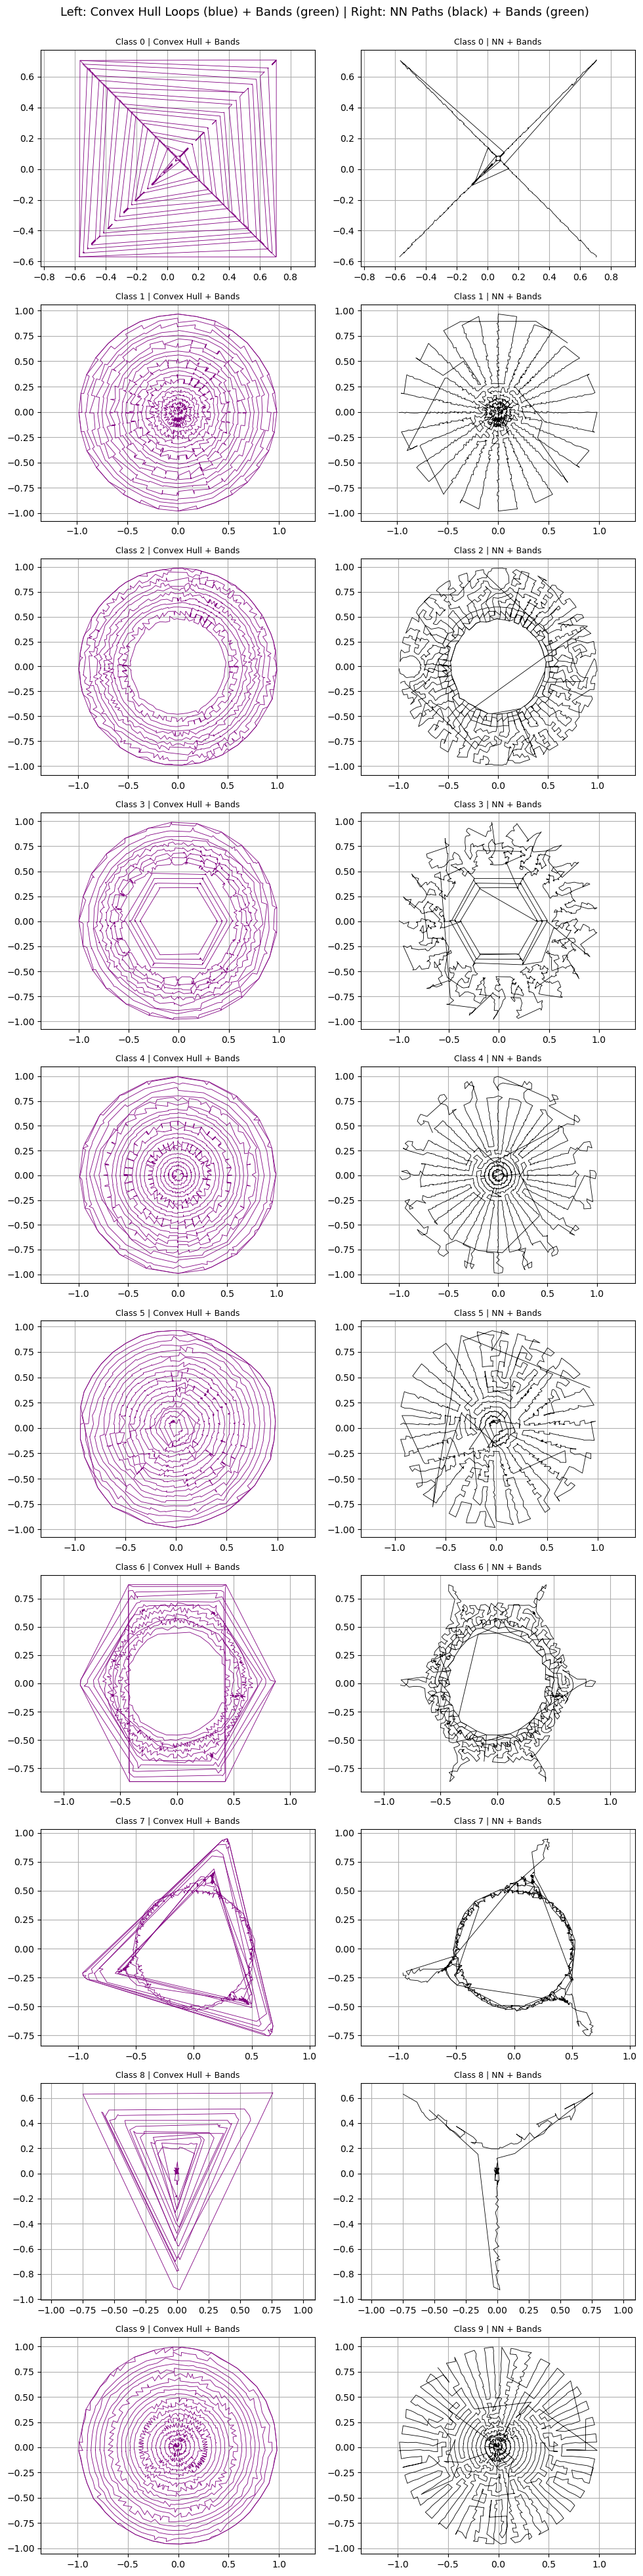

In [13]:
# =====================================================
# Plot Results (2 Columns: Convex Hull + Bands vs NN + Bands)
# =====================================================
rows, cols = num_classes, 2
fig, axs = plt.subplots(rows, cols, figsize=(10, 40))

for i in range(num_classes):
    pts = np.unique(np.round(decoded[i], 6), axis=0)

    # --- Band Layers (common base) ---
    loops, all_pts, band_indices, r_band = multilayer_bands_origin(
        pts, band_width=0.05, max_layers=3
    )

    # =====================================================
    # LEFT COLUMN → Convex Hull + Bands
    # =====================================================
    ax_left = axs[i, 0]
    ax_left.scatter(all_pts[:, 0], all_pts[:, 1], s=0.6, color="white")

    # Plot the band loops (green)
    for loop in loops:
        ax_left.plot(loop[:, 0], loop[:, 1], '-', lw=0.6, color="purple")

    # Add convex hull nested layers (blue)
    layers = nested_loops_with_hull(all_pts, band_indices, r_band, step=0.05)
    for layer in layers:
        ax_left.plot(layer[:, 0], layer[:, 1], '-', color="purple", lw=0.6)

    ax_left.set_title(f"Class {i} | Convex Hull + Bands", fontsize=9)
    ax_left.axis("equal")
    ax_left.grid(True)

    # =====================================================
    # RIGHT COLUMN → Nearest Neighbor + Bands
    # =====================================================
    ax_right = axs[i, 1]
    ax_right.scatter(all_pts[:, 0], all_pts[:, 1], s=0.6, color="white")

    # Plot the band loops (green)
    for loop in loops:
        ax_right.plot(loop[:, 0], loop[:, 1], '-', lw=0.6, color="black")

    # Add nearest neighbor path (black)
    path = nearest_neighbor_path(all_pts)
    if path is not None:
        ax_right.plot(path[:, 0], path[:, 1], '-', color="black", lw=0.6)

    ax_right.set_title(f"Class {i} | NN + Bands", fontsize=9)
    ax_right.axis("equal")
    ax_right.grid(True)

# =====================================================
# Figure Title
# =====================================================
plt.suptitle(
    "Left: Convex Hull Loops (blue) + Bands (green) | Right: NN Paths (black) + Bands (green)",
    fontsize=13
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



✅ G-code successfully generated and saved to:
F:\JupyterWork\Testing GAN\Coding of GAN\Output\gan_generated_shift30mm.gcode


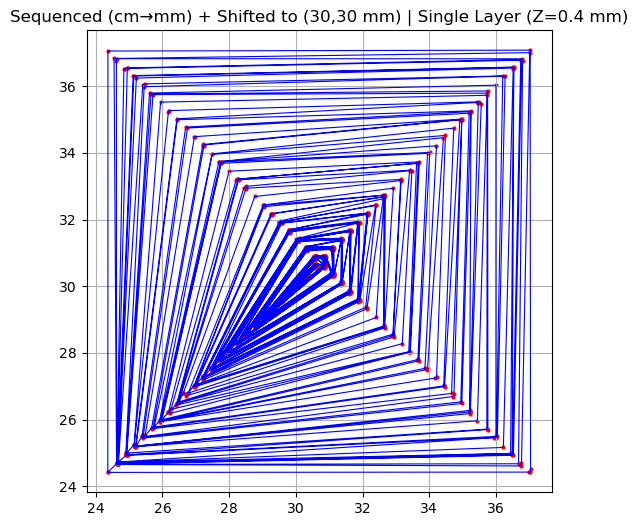

In [17]:
# =====================================================
# Final GAN → G-code (1 Layer, Custom Header + Extrusion)
# Convex Hull sequencing | Generated points in cm → convert to mm
# Centroid shift = (30, 30) mm | Z=0.4 | Feedrate=800
# =====================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.spatial import ConvexHull

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt")
gcode_output   = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\Output\gan_generated_shift30mm.gcode")

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2030
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )

    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out


class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )

    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Convex Hull Sequencing
# =====================================================
def convex_hull_inward_sequence(points, step=0.05):
    """Generate nested convex hull loops from outside → inward."""
    if len(points) < 3:
        return points

    points = points.copy()
    ordered_path = []
    dists = np.sqrt(points[:, 0]**2 + points[:, 1]**2)
    r_min, r_max = dists.min(), dists.max()

    current_points = points
    current_r = r_max
    while len(current_points) > 3 and current_r > r_min + step:
        try:
            hull = ConvexHull(current_points)
            hull_points = current_points[hull.vertices]
            angles = np.arctan2(hull_points[:, 1], hull_points[:, 0])
            order = np.argsort(angles)
            hull_ordered = hull_points[order]
            hull_ordered = np.vstack([hull_ordered, hull_ordered[0]])
            ordered_path.append(hull_ordered)

            mask = np.ones(len(current_points), dtype=bool)
            mask[hull.vertices] = False
            current_points = current_points[mask]
            if len(current_points) == 0:
                break
            dists = np.sqrt(current_points[:, 0]**2 + current_points[:, 1]**2)
            current_r = dists.max()
        except Exception as e:
            print("Hull error:", e)
            break

    if ordered_path:
        return np.vstack(ordered_path)
    else:
        return points

# =====================================================
# Load Models
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# Generate Sample (Class 0, Area = 1.00)
# =====================================================
with torch.no_grad():
    z_noise = torch.randn(1, latent_size).to(device)
    label = torch.tensor([0]).to(device)
    label_onehot = F.one_hot(label, num_classes=num_classes).float().to(device)
    area = torch.tensor([[1.0]], dtype=torch.float32).to(device)
    cond = torch.cat([area, label_onehot], dim=1)
    fake_latent = G(z_noise, cond)
    decoded = cae(fake_latent, cond).cpu().numpy()[0]

# =====================================================
# Process: Sequence first (in cm), then scale to mm, then shift to (30,30)
# =====================================================
points = np.unique(np.round(decoded, 6), axis=0)
ordered_points = convex_hull_inward_sequence(points, step=0.05)

# convert cm → mm
ordered_points *= 10

# shift centroid to (30, 30) mm
centroid = ordered_points.mean(axis=0)
ordered_points -= centroid
ordered_points += np.array([30, 30])

# =====================================================
# Construct G-code
# =====================================================
os.makedirs(gcode_output.parent, exist_ok=True)
feedrate = 800
z_height = 0.4
E_per_mm = 0.02
extrusion = 0.0

# --- Custom Header ---
header = [
    "G90",
    "M82",
    "M106 S0",
    "M140 S60",
    "M190 S60",
    "M104 S180 T0",
    "M109 S180 T0",
    "G92 A0 ; zero extruder",
    "G28 ; home all axes",
    "G1 Z0.4 ; position nozzle",
    "G1 X10 Y10 ; prepare to extrude",
    "G1 X210 Y10 E12.5 F800; Extrude line",
    "M73 P1 ;@body (notify GPX body has started)",
    "; process Process1",
    "; layer 1, Z = 0.196",
    "T0",
    "G92 E0.0000",
    ""
]

# --- G1 X,Y moves (each with its own E increment) ---
lines = []
prev_x, prev_y = ordered_points[0]
for x, y in ordered_points:
    dist = np.sqrt((x - prev_x)**2 + (y - prev_y)**2)
    extrusion += dist * E_per_mm
    lines.append(f"G1 X{x:.3f} Y{y:.3f} Z{z_height:.3f} E{extrusion:.4f} F{feedrate}")
    prev_x, prev_y = x, y

# --- Footer ---
footer = [
    "",
    "G92 E0",
    "G1 E-1 F1800 ; retract",
    "G1 Z5 F3000 ; move Z up",
    "M104 S0 ; turn off extruder",
    "M140 S0 ; turn off bed",
    "M107 ; turn off fan",
    "G28 X0 Y0 ; home XY axes",
    "M84 ; disable motors",
    "; End of print"
]

# --- Write G-code ---
with open(gcode_output, "w", encoding="utf-8") as f:
    f.write("\n".join(header + lines + footer))

print(f"\n✅ G-code successfully generated and saved to:\n{gcode_output}")

# =====================================================
# Visualization
# =====================================================
plt.figure(figsize=(6,6))
plt.plot(ordered_points[:,0], ordered_points[:,1], '-', lw=0.8, color="blue")
plt.scatter(ordered_points[:,0], ordered_points[:,1], s=4, color="red")
plt.title("Sequenced (cm→mm) + Shifted to (30,30 mm) | Single Layer (Z=0.4 mm)")
plt.axis("equal")
plt.grid(True)
plt.show()
